# SSC calibration and $\kappa(c)$ (cells 49–57 of the original notebook)

SSC clip ratios on optimizer snapshots, the rank-normalized energy $\kappa(c)$
across r=64 and r=256 runs, and MISR↔SVD agreement.

**Source taxonomy used in this notebook**

- **Magicoder snapshots**: OLMo-2-0425-1B default; `data/magicoder_seq512_70k_packed`; `packed_v1`; seq512; 4k-step snapshots.
- **OLMo OPC snapshots**: `allenai/OLMo-2-0425-1B`; `data/opc_sft_stage2_all_packed_seq2048`; `packed_v1.1`; seq2048; 9k-step snapshots.
- **Snapshot q_agree**: `agreement_kappa_diagnostic()` over `optimizer.pt` snapshots. This is not the same source as JSONL `optim_step.awc_q_agree_*`.
- **JSONL q_agree**: `optim_step.awc_q_agree_*` emitted in training logs, used for the Llama/OLMo OPC diagnostic comparison outside this snapshot notebook.

The snapshot registry currently mixes Magicoder snapshots and OLMo OPC snapshots. Any cross-source comparison below should be treated as diagnostic only, not as architecture evidence.


In [17]:
%load_ext autoreload
%autoreload 2

import sys
if '/mnt/home/nghosh/lora' not in sys.path:
    sys.path.insert(0, '/mnt/home/nghosh/lora')

import json
import shlex
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from lora_playground.snapshot_analysis import (
    # snapshot registry + cached loader
    SNAP_ROOT, SNAP_ROOTS, STEPS, STEPS_BY_ROOT,
    RUNS, RUN_A, RUN_B, RUN_C, RUN_D, RUN_E, RUN_F,
    load_snapshot, clear_snapshot_cache,
    # adam-moment / spectrum helpers
    Mtilde, normalized_sigmas, normalized_sigmas_x, stable_rank,
    EPS, BETA1, BETA2,
    # whitening
    spd_half_inv, whitened_NS_input, DELTA_ABS,
    # SSC / polar shape
    _prerescale_unit_op, _polar_uvt, _ssc_svd, _ssc_misr_batched,
    # diagnostic NS iteration (trajectory-returning)
    newton_schulz_polar, polar_express,
)

DEV = SSC_DEV = 'cuda' if torch.cuda.is_available() else 'cpu'


def _argv_value(tokens, flag, default=None):
    if flag not in tokens:
        return default
    i = tokens.index(flag)
    return tokens[i + 1] if i + 1 < len(tokens) else default


def _snapshot_command(root):
    step0 = root / 'step_0' / 'meta.json'
    if not step0.exists():
        return ''
    meta = json.loads(step0.read_text())
    return meta.get('cfg_snapshot', {}).get('command', '') or meta.get('command', '')


def _source_full(data_dir, pipeline):
    data_dir = data_dir or ''
    pipeline = pipeline or '?'
    if 'magicoder' in data_dir:
        return 'Magicoder snapshots: OLMo-2-0425-1B default; data/magicoder_seq512_70k_packed; packed_v1; seq512; 4k-step snapshots'
    if 'opc_sft_stage2' in data_dir:
        return 'OLMo OPC snapshots: allenai/OLMo-2-0425-1B; data/opc_sft_stage2_all_packed_seq2048; packed_v1.1; seq2048; 9k-step snapshots'
    return f'unknown snapshot source: {data_dir}; {pipeline}'


def _source_short(data_dir, pipeline):
    data_dir = data_dir or ''
    pipeline = pipeline or '?'
    if 'magicoder' in data_dir:
        return 'Magicoder snapshots'
    if 'opc_sft_stage2' in data_dir:
        return 'OLMo OPC snapshots'
    return f'unknown {pipeline} snapshots'


def snapshot_source_table(runs=RUNS):
    rows = []
    for run_key in runs:
        root = SNAP_ROOTS[run_key]
        command = _snapshot_command(root)
        tokens = shlex.split(command) if command else []
        data_dir = _argv_value(tokens, '--data_dir', '?')
        pipeline = _argv_value(tokens, '--data_pipeline_version', '?')
        rows.append({
            'run_key': run_key,
            'lr': run_key[0],
            'lora_r': run_key[1],
            'ns': run_key[2],
            'variant': run_key[3],
            'source_short': _source_short(data_dir, pipeline),
            'source_full': _source_full(data_dir, pipeline),
            'data_dir': data_dir,
            'pipeline': pipeline,
            'root': str(root),
        })
    return pd.DataFrame(rows)


SNAPSHOT_SOURCE_DF = snapshot_source_table(RUNS)
SNAPSHOT_SOURCE_BY_RUN = {
    tuple(row['run_key']): row.to_dict()
    for _, row in SNAPSHOT_SOURCE_DF.iterrows()
}


def _row_run_key(row):
    return (str(row['lr']), int(row['lora_r']), int(row['ns']), str(row['variant']))


def run_source_label(run_key):
    rec = SNAPSHOT_SOURCE_BY_RUN.get(tuple(run_key))
    return rec['source_short'] if rec is not None else 'unknown snapshots'


def add_snapshot_source(df):
    if df.empty:
        return df.copy()
    out = df.copy()
    records = out.apply(
        lambda r: SNAPSHOT_SOURCE_BY_RUN.get(_row_run_key(r), {}),
        axis=1,
    )
    out['source_short'] = [r.get('source_short', 'unknown snapshots') for r in records]
    out['source_full'] = [r.get('source_full', 'unknown snapshot source') for r in records]
    out['data_dir'] = [r.get('data_dir', '?') for r in records]
    out['pipeline'] = [r.get('pipeline', '?') for r in records]
    return out


print(f'device: {DEV}')
print(f'active RUNS: {RUNS}')
print(f'default STEPS: {STEPS}')
display(SNAPSHOT_SOURCE_DF[[
    'source_short', 'source_full', 'variant', 'lora_r', 'lr', 'ns',
    'data_dir', 'pipeline', 'root',
]])


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda
active RUNS: [('3e-2', 64, 5, 'chord-tight'), ('1e-1', 64, 5, 'chord-tight'), ('1e-3', 256, 10, 'chord-tight-clean'), ('1e-1', 256, 10, 'chord-tight-clean'), ('3e-2', 64, 5, 'chord-tight-k1'), ('3e-2', 256, 5, 'chord-tight-k1')]
default STEPS: [0, 50, 200, 500, 1000, 2000, 4000]


,source_short,source_full,variant,lora_r,lr,ns,data_dir,pipeline,root
0,Magicoder snapshots,Magicoder snapshots: OLMo-2-0425-1B default; d...,chord-tight,64,3e-2,5,data/magicoder_seq512_70k_packed,packed_v1,/mnt/ceph/users/nghosh/lora_snapshots/chord_ti...
1,Magicoder snapshots,Magicoder snapshots: OLMo-2-0425-1B default; d...,chord-tight,64,1e-1,5,data/magicoder_seq512_70k_packed,packed_v1,/mnt/ceph/users/nghosh/lora_snapshots/chord_ti...
2,Magicoder snapshots,Magicoder snapshots: OLMo-2-0425-1B default; d...,chord-tight-clean,256,1e-3,10,data/magicoder_seq512_70k_packed,packed_v1,/mnt/ceph/users/nghosh/lora_snapshots/chord_ti...
3,Magicoder snapshots,Magicoder snapshots: OLMo-2-0425-1B default; d...,chord-tight-clean,256,1e-1,10,data/magicoder_seq512_70k_packed,packed_v1,/mnt/ceph/users/nghosh/lora_snapshots/chord_ti...
4,OLMo OPC snapshots,OLMo OPC snapshots: allenai/OLMo-2-0425-1B; da...,chord-tight-k1,64,3e-2,5,data/opc_sft_stage2_all_packed_seq2048,packed_v1.1,/mnt/ceph/users/nghosh/lora_snapshots/chord_ti...
5,OLMo OPC snapshots,OLMo OPC snapshots: allenai/OLMo-2-0425-1B; da...,chord-tight-k1,256,3e-2,5,data/opc_sft_stage2_all_packed_seq2048,packed_v1.1,/mnt/ceph/users/nghosh/lora_snapshots/chord_ti...


## SSC (Soft Spectral Clipping) calibration on real snapshots

SPECTRA (arXiv:2603.14315) defines $H_c(X) = (I + XX^T/c^2)^{-1/2}\,X$, equivalently $\sigma_i \mapsto \sigma_i/\sqrt{1 + (\sigma_i/c)^2}$. Inside the chord-tight pipeline the polar input is pre-rescaled so $\sigma_{\max}(X_A) = 1$, so $c$ is **dimensionless** and only acts in $[\sigma_{\min}, 1]$. The paper's recommended $c{=}10$ is in their (unrescaled) units; in our normalized setting $h_{10}(1) \approx 0.995$ — essentially identity.

**Source warning.** The snapshot registry above is mixed: the k=3 / clean-k=3 snapshots are Magicoder packed-v1 runs, while the k=1 snapshots are OLMo OPC packed-v1.1 runs. Do not compare source-mixed rows as architecture or dataset evidence. Llama `q_agree` values discussed separately come from JSONL `optim_step` diagnostics, not these snapshots.

**This cell measures, on the default real snapshot source, which $c$ values actually clip.** If no $c$ in the grid below moves the F-norm ratio meaningfully off $1.0$, the SSC hypothesis is dead and the planned sweep won't run.

For each step and pair, we compute on the §2.5-rescaled whitened input:
- $\|H_c(X_A)\|_{op} / \|X_A\|_{op}$ — operator-norm cap.
- $\|H_c(X_A)\|_F / \|X_A\|_F$ — F-norm reduction (this is what the operator-norm magnitude rule sees through stable-rank).


In [18]:
# ssc_calibration lives in lora_playground.snapshot_analysis.calibration.
from lora_playground.snapshot_analysis.calibration import ssc_calibration

print(f'SSC calibration device: {SSC_DEV}')
print(f'default snapshot source: {run_source_label(RUN_A)}')
df_ssc = ssc_calibration()
df_ssc['source_short'] = run_source_label(RUN_A)
print(f'rows={len(df_ssc)}, steps={sorted(df_ssc.step.unique())}, c grid={sorted(df_ssc.c.unique())}')
print()
print('=== F-norm ratio  ||H_c(X)||_F / ||X||_F  (median across pairs, step x c) ===')
print(df_ssc.pivot_table(values='f_ratio', index='step', columns='c', aggfunc='median').round(3))
print()
print('=== Op-norm ratio  ||H_c(X)||_op / ||X||_op  (median across pairs, step x c) ===')
print(df_ssc.pivot_table(values='op_ratio', index='step', columns='c', aggfunc='median').round(3))
print()
print('=== F-norm ratio MAX across pairs (lightest clipping) ===')
print(df_ssc.pivot_table(values='f_ratio', index='step', columns='c', aggfunc='max').round(3))
print()
print('=== F-norm ratio MIN across pairs (heaviest clipping) ===')
print(df_ssc.pivot_table(values='f_ratio', index='step', columns='c', aggfunc='min').round(3))
print()
print('=== Stable rank: input X vs H_c(X)  (median, step=2000) ===')
sub = df_ssc[df_ssc.step == 2000]
print(sub.pivot_table(values=['stable_rank_X', 'stable_rank_H'], columns='c', aggfunc='median').round(2))


SSC calibration device: cuda
default snapshot source: Magicoder snapshots
rows=432, steps=[np.int64(200), np.int64(1000), np.int64(2000), np.int64(4000)], c grid=[np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(10.0)]

=== F-norm ratio  ||H_c(X)||_F / ||X||_F  (median across pairs, step x c) ===
c      0.1    0.2    0.3    0.5    0.7    1.0    2.0    5.0    10.0
step                                                               
200   0.279  0.465  0.583  0.728  0.811  0.883  0.962  0.993  0.998
1000  0.294  0.463  0.575  0.717  0.796  0.868  0.956  0.992  0.998
2000  0.290  0.455  0.566  0.706  0.787  0.859  0.952  0.991  0.998
4000  0.285  0.439  0.545  0.686  0.774  0.854  0.950  0.991  0.998

=== Op-norm ratio  ||H_c(X)||_op / ||X||_op  (median across pairs, step x c) ===
c     0.1    0.2    0.3    0.5    0.7    1.0    2.0    5.0    10.0
step                                           

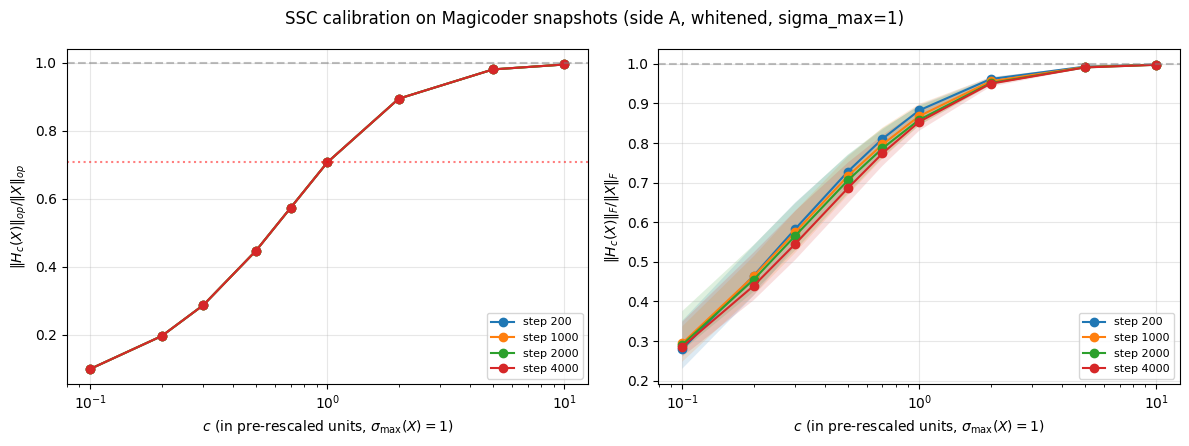

In [19]:
# Plot calibration ratios vs c, overlaid per step.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for step in sorted(df_ssc.step.unique()):
    sub = df_ssc[df_ssc.step == step].groupby('c').agg({'op_ratio': ['min', 'max', 'median'],
                                                        'f_ratio': ['min', 'max', 'median']})
    cs = sub.index.values
    axes[0].plot(cs, sub[('op_ratio', 'median')], marker='o', label=f'step {step}')
    axes[0].fill_between(cs, sub[('op_ratio', 'min')], sub[('op_ratio', 'max')], alpha=0.15)
    axes[1].plot(cs, sub[('f_ratio', 'median')], marker='o', label=f'step {step}')
    axes[1].fill_between(cs, sub[('f_ratio', 'min')], sub[('f_ratio', 'max')], alpha=0.15)
for ax, ylab in zip(axes, [r'$\|H_c(X)\|_{op} / \|X\|_{op}$',
                            r'$\|H_c(X)\|_F / \|X\|_F$']):
    ax.set_xscale('log')
    ax.set_xlabel(r'$c$ (in pre-rescaled units, $\sigma_{\max}(X) = 1$)')
    ax.set_ylabel(ylab)
    ax.axhline(1.0, ls='--', color='gray', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].axhline(1/np.sqrt(2), ls=':', color='red', alpha=0.5)
fig.suptitle(f'SSC calibration on {run_source_label(RUN_A)} (side A, whitened, sigma_max=1)')
fig.tight_layout()
plt.show()


### $\kappa(c)$: rank-normalized spectral energy of the SSC output

For the smooth saturating shape family $h_c(s) = s/\sqrt{1 + (s/c)^2}$, with input
pre-rescaled to $\sigma_{\max}(X) = 1$, define

$$\kappa(c) \;=\; \frac{1}{r}\,\frac{\|H_c(X)\|_F^2}{\|H_c(X)\|_{\mathrm{op}}^2}
\;=\; \frac{\mathrm{stable\_rank}(H_c(X))}{r}.$$

Interpretation: fraction of the rank-normalized spectral energy used by the update.
$\kappa \to 1/r$ is rank-one (input passthrough on a heavy-tailed spectrum);
$\kappa \to 1$ is polar (uniform spectrum). The hypothesis we want to test on real
snapshots: holding $\kappa$ fixed, the required $c$ shrinks with $r$, but the *update
shape* is rank-invariant.

The labels include the snapshot source because this registry currently mixes Magicoder packed-v1 snapshots and OLMo OPC packed-v1.1 snapshots.


rows=120
runs:


,source_short,variant,lora_r,lr,ns
0,Magicoder snapshots,chord-tight,64,1e-1,5
1,Magicoder snapshots,chord-tight,64,3e-2,5
2,Magicoder snapshots,chord-tight-clean,256,1e-1,10
3,Magicoder snapshots,chord-tight-clean,256,1e-3,10
4,OLMo OPC snapshots,chord-tight-k1,64,3e-2,5
5,OLMo OPC snapshots,chord-tight-k1,256,3e-2,5



=== kappa(c)  median across pairs+steps, per source/run ===


c                                                     0.05   0.10   0.20   \
source_short        variant           lora_r lr   ns                        
Magicoder snapshots chord-tight       64     1e-1 5   0.631  0.421  0.231   
                                             3e-2 5   0.818  0.623  0.394   
                    chord-tight-clean 256    1e-1 10  0.833  0.626  0.378   
                                             1e-3 10  0.763  0.507  0.262   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5   0.900  0.746  0.527   
                                      256    3e-2 5   0.878  0.682  0.417   

c                                                     0.30   0.50   0.70   \
source_short        variant           lora_r lr   ns                        
Magicoder snapshots chord-tight       64     1e-1 5   0.153  0.092  0.069   
                                             3e-2 5   0.279  0.174  0.130   
                    chord-tight-clean 256    1e-1 10  0.258  0.152  0.110   
                                             1e-3 10  0.164  0.089  0.062   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5   0.395  0.257  0.193   
                                      256    3e-2 5   0.283  0.165  0.118   

c                                                     1.00   2.00   5.00   \
source_short        variant           lora_r lr   ns                        
Magicoder snapshots chord-tight       64     1e-1 5   0.055  0.044  0.040   
                                             3e-2 5   0.100  0.075  0.067   
                    chord-tight-clean 256    1e-1 10  0.082  0.059  0.051   
                                             1e-3 10  0.045  0.032  0.028   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5   0.148  0.108  0.096   
                                      256    3e-2 5   0.088  0.062  0.054   

c                                                     10.00  
source_short        variant           lora_r lr   ns         
Magicoder snapshots chord-tight       64     1e-1 5   0.040  
                                             3e-2 5   0.066  
                    chord-tight-clean 256    1e-1 10  0.050  
                                             1e-3 10  0.027  
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5   0.094  
                                      256    3e-2 5   0.053


=== kappa(input) (no SSC) median per source/run ===


,source_short,variant,lora_r,lr,ns,kappa_input
0,Magicoder snapshots,chord-tight,64,1e-1,5,0.039
1,Magicoder snapshots,chord-tight,64,3e-2,5,0.066
2,Magicoder snapshots,chord-tight-clean,256,1e-1,10,0.050
3,Magicoder snapshots,chord-tight-clean,256,1e-3,10,0.027
4,OLMo OPC snapshots,chord-tight-k1,64,3e-2,5,0.093
5,OLMo OPC snapshots,chord-tight-k1,256,3e-2,5,0.053



=== kappa(c) median, sliced by step: source/run/step x c ===


c                                                          0.05   0.10   \
source_short        variant           lora_r lr   ns step                 
Magicoder snapshots chord-tight       64     1e-1 5  4000  0.631  0.421   
                                             3e-2 5  4000  0.818  0.623   
                    chord-tight-clean 256    1e-1 10 4000  0.833  0.626   
                                             1e-3 10 4000  0.763  0.507   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5  4000  0.900  0.746   
                                      256    3e-2 5  4000  0.878  0.682   

c                                                          0.20   0.30   \
source_short        variant           lora_r lr   ns step                 
Magicoder snapshots chord-tight       64     1e-1 5  4000  0.231  0.153   
                                             3e-2 5  4000  0.394  0.279   
                    chord-tight-clean 256    1e-1 10 4000  0.378  0.258   
                                             1e-3 10 4000  0.262  0.164   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5  4000  0.527  0.395   
                                      256    3e-2 5  4000  0.417  0.283   

c                                                          0.50   0.70   \
source_short        variant           lora_r lr   ns step                 
Magicoder snapshots chord-tight       64     1e-1 5  4000  0.092  0.069   
                                             3e-2 5  4000  0.174  0.130   
                    chord-tight-clean 256    1e-1 10 4000  0.152  0.110   
                                             1e-3 10 4000  0.089  0.062   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5  4000  0.257  0.193   
                                      256    3e-2 5  4000  0.165  0.118   

c                                                          1.00   2.00   \
source_short        variant           lora_r lr   ns step                 
Magicoder snapshots chord-tight       64     1e-1 5  4000  0.055  0.044   
                                             3e-2 5  4000  0.100  0.075   
                    chord-tight-clean 256    1e-1 10 4000  0.082  0.059   
                                             1e-3 10 4000  0.045  0.032   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5  4000  0.148  0.108   
                                      256    3e-2 5  4000  0.088  0.062   

c                                                          5.00   10.00  
source_short        variant           lora_r lr   ns step                
Magicoder snapshots chord-tight       64     1e-1 5  4000  0.040  0.040  
                                             3e-2 5  4000  0.067  0.066  
                    chord-tight-clean 256    1e-1 10 4000  0.051  0.050  
                                             1e-3 10 4000  0.028  0.027  
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5  4000  0.096  0.094  
                                      256    3e-2 5  4000  0.054  0.053

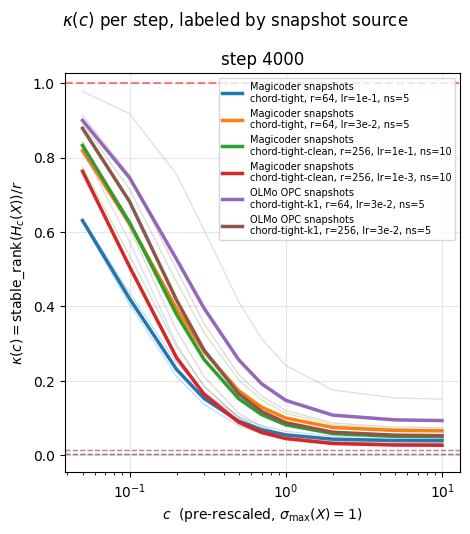

In [20]:
# kappa_calibration lives in lora_playground.snapshot_analysis.calibration.
from lora_playground.snapshot_analysis.calibration import kappa_calibration

df_kappa = add_snapshot_source(kappa_calibration())
run_cols = ['source_short', 'variant', 'lora_r', 'lr', 'ns']

print(f'rows={len(df_kappa)}')
print('runs:')
display(df_kappa[run_cols].drop_duplicates().sort_values(run_cols).reset_index(drop=True))

print()
print('=== kappa(c)  median across pairs+steps, per source/run ===')
piv = df_kappa.pivot_table(values='kappa',
                           index=run_cols, columns='c', aggfunc='median').round(3)
display(piv)

print()
print('=== kappa(input) (no SSC) median per source/run ===')
display(df_kappa.groupby(run_cols)['kappa_input'].median().round(3).reset_index())

print()
print('=== kappa(c) median, sliced by step: source/run/step x c ===')
piv2 = df_kappa.pivot_table(values='kappa',
                            index=run_cols + ['step'], columns='c',
                            aggfunc='median').round(3)
display(piv2)

# --- Overlay: kappa(c) per source/run, one panel per step. ----------------
# Color = source/run. Faint = individual pairs (no aggregation).
# Bold = mean-over-pairs as a visual anchor. Rank-shift in c shows as a
# horizontal offset between colored bands within each panel; step-drift shows
# as a change between panels.
steps_plot = sorted(df_kappa['step'].unique())
runs_present = sorted(df_kappa[run_cols].drop_duplicates()
                      .itertuples(index=False, name=None))
run_colors = {rk: f'C{i % 10}' for i, rk in enumerate(runs_present)}

fig, axes = plt.subplots(1, len(steps_plot),
                         figsize=(4.8 * len(steps_plot), 5.4),
                         sharey=True, squeeze=False)
axes = axes[0]
for ax, step in zip(axes, steps_plot):
    df_step = df_kappa[df_kappa['step'] == step]
    for run_vals in runs_present:
        source, variant, r_val, lr_val, ns_val = run_vals
        color = run_colors[run_vals]
        sub_run = df_step[
            (df_step.source_short == source)
            & (df_step.variant == variant)
            & (df_step.lora_r == r_val)
            & (df_step.lr == lr_val)
            & (df_step.ns == ns_val)
        ]
        if sub_run.empty:
            continue
        for pi, g in sub_run.groupby('pair'):
            g = g.sort_values('c')
            ax.plot(g['c'].values, g['kappa'].values,
                    color=color, alpha=0.25, lw=0.9)
        mean_curve = sub_run.groupby('c')['kappa'].mean().sort_index()
        ax.plot(mean_curve.index.values, mean_curve.values,
                color=color, lw=2.5,
                label=f'{source}\n{variant}, r={r_val}, lr={lr_val}, ns={ns_val}')
        ax.axhline(1.0 / r_val, ls='--', color=color, alpha=0.4, lw=1.0)
    ax.axhline(1.0, ls='--', color='red', alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel(r'$c$  (pre-rescaled, $\sigma_{\max}(X)=1$)')
    ax.set_title(f'step {step}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel(r'$\kappa(c) = \mathrm{stable\_rank}(H_c(X)) / r$')
axes[-1].legend(fontsize=7, loc='best')
fig.suptitle(r'$\kappa(c)$ per step, labeled by snapshot source')
fig.tight_layout()
plt.show()


### Local-objective optimum over $c$

One compact snapshot replay: sweep SSC $c$, score the local chord-tight surrogate, and show whether the preferred $c$ is interior or pinned at the grid edge.


snapshot sources used in this local objective cell:


,source_short,variant,lora_r,lr,ns,data_dir,pipeline
0,Magicoder snapshots,chord-tight,64,3e-2,5,data/magicoder_seq512_70k_packed,packed_v1
1,Magicoder snapshots,chord-tight-clean,256,1e-1,10,data/magicoder_seq512_70k_packed,packed_v1
2,OLMo OPC snapshots,chord-tight-k1,256,3e-2,5,data/opc_sft_stage2_all_packed_seq2048,packed_v1.1


local c-grid: ('3e-2', 64, 5, 'chord-tight') step=4000 device=cuda
local c-grid: ('1e-1', 256, 10, 'chord-tight-clean') step=4000 device=cuda
local c-grid: ('3e-2', 256, 5, 'chord-tight-k1') step=4000 device=cuda
rows=48, best rows=24
=== median best c by objective / source / run / step ===


median  \
                                                                             best_c   
objective          source_short        variant           lora_r lr   ns step          
obj_raw_chord      Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01   
                                       chord-tight-clean 256    1e-1 10 4000   0.01   
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.01   
obj_raw_tangent    Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01   
                                       chord-tight-clean 256    1e-1 10 4000   0.01   
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.01   
obj_scaled_chord   Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01   
                                       chord-tight-clean 256    1e-1 10 4000   0.01   
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.05   
obj_scaled_tangent Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01   
                                       chord-tight-clean 256    1e-1 10 4000   0.01   
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.05   

                                                                                min  \
                                                                             best_c   
objective          source_short        variant           lora_r lr   ns step          
obj_raw_chord      Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01   
                                       chord-tight-clean 256    1e-1 10 4000   0.01   
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.01   
obj_raw_tangent    Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01   
                                       chord-tight-clean 256    1e-1 10 4000   0.01   
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.01   
obj_scaled_chord   Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01   
                                       chord-tight-clean 256    1e-1 10 4000   0.01   
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.05   
obj_scaled_tangent Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01   
                                       chord-tight-clean 256    1e-1 10 4000   0.01   
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.05   

                                                                                max  
                                                                             best_c  
objective          source_short        variant           lora_r lr   ns step         
obj_raw_chord      Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01  
                                       chord-tight-clean 256    1e-1 10 4000   0.01  
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.01  
obj_raw_tangent    Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01  
                                       chord-tight-clean 256    1e-1 10 4000   0.01  
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.01  
obj_scaled_chord   Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01  
                                       chord-tight-clean 256    1e-1 10 4000   0.01  
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.05  
obj_scaled_tangent Magicoder snapshots chord-tight       64     3e-2 5  4000   0.01  
                                       chord-tight-clean 256    1e-1 10 4000   0.01  
                   OLMo OPC snapshots  chord-tight-k1    256    3e-2 5  4000   0.05

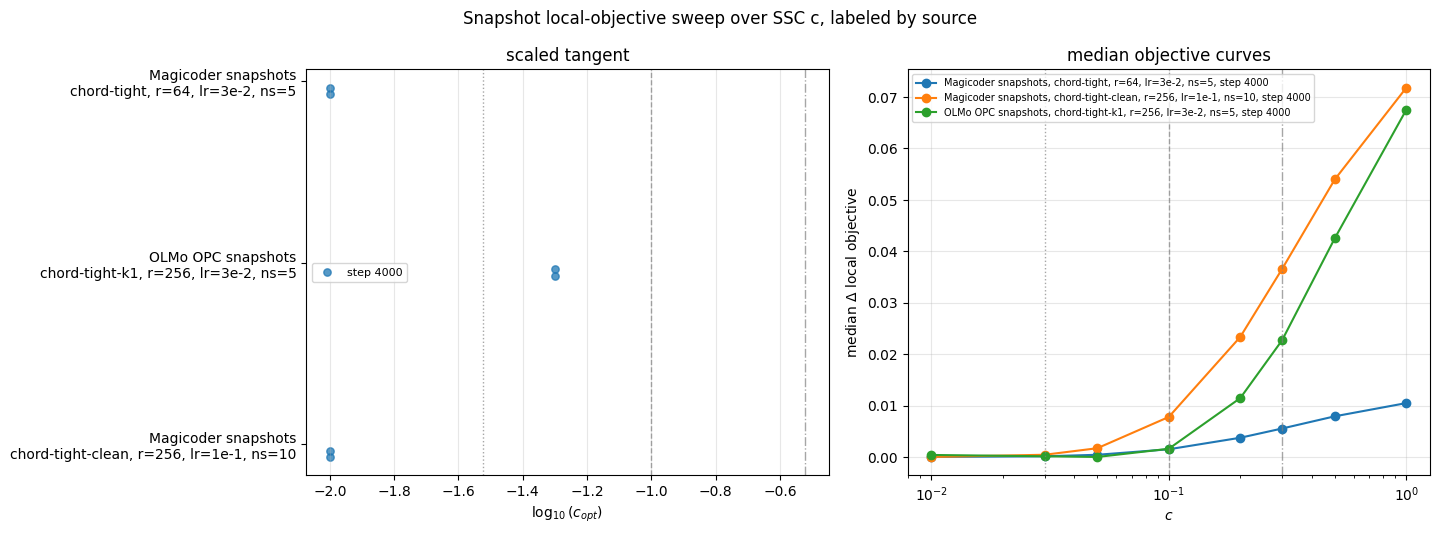

In [21]:
from lora_playground.snapshot_analysis.calibration import (
    local_objective_c_grid,
    best_c_by_snapshot_objective,
)

LOCAL_C_RUNS = [RUN_A, RUN_B, RUN_F]
LOCAL_C_STEPS = (4000,)
LOCAL_C_GRID = (0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0)
LOCAL_C_N_PAIRS = 2
LOCAL_C_PICARD_ITERS = 3
objective_to_plot = 'obj_scaled_tangent'

print('snapshot sources used in this local objective cell:')
display(snapshot_source_table(LOCAL_C_RUNS)[[
    'source_short', 'variant', 'lora_r', 'lr', 'ns', 'data_dir', 'pipeline',
]])

df_cobj = add_snapshot_source(local_objective_c_grid(
    runs=LOCAL_C_RUNS,
    steps=LOCAL_C_STEPS,
    cs=LOCAL_C_GRID,
    n_pairs=LOCAL_C_N_PAIRS,
    picard_iters=LOCAL_C_PICARD_ITERS,
    device=SSC_DEV,
    verbose=True,
))
objective_cols = ['obj_scaled_tangent', 'obj_scaled_chord', 'obj_raw_tangent', 'obj_raw_chord']
df_cbest = pd.concat([
    best_c_by_snapshot_objective(df_cobj, objective_col=o).assign(objective=o)
    for o in objective_cols
], ignore_index=True)

print(f'rows={len(df_cobj)}, best rows={len(df_cbest)}')
print('=== median best c by objective / source / run / step ===')
display(df_cbest.pivot_table(
    values='best_c',
    index=['objective', 'source_short', 'variant', 'lora_r', 'lr', 'ns', 'step'],
    aggfunc=['median', 'min', 'max'],
).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

# Left: best-c distribution for the main objective.
sub_best = df_cbest[df_cbest.objective == objective_to_plot].copy()
sub_best['run_label'] = sub_best.apply(
    lambda r: f'{r.source_short}\n{r.variant}, r={r.lora_r}, lr={r.lr}, ns={r.ns}',
    axis=1,
)
run_labels = list(sub_best['run_label'].drop_duplicates())
run_order = {label: i for i, label in enumerate(run_labels)}
for step, g_step in sub_best.groupby('step'):
    y = g_step['run_label'].map(run_order).to_numpy(dtype=float)
    jitter = ((g_step['pair'].to_numpy() % 5) - 2) * 0.035
    axes[0].scatter(np.log10(g_step['best_c'].to_numpy()), y + jitter,
                    s=28, alpha=0.75, label=f'step {step}')
for c_ref, style in [(0.03, ':'), (0.1, '--'), (0.3, '-.')]:
    axes[0].axvline(np.log10(c_ref), color='gray', ls=style, lw=1.0, alpha=0.7)
axes[0].set_yticks(range(len(run_labels)))
axes[0].set_yticklabels(run_labels)
axes[0].set_xlabel(r'$\log_{10}(c_{opt})$')
axes[0].set_title(objective_to_plot.replace('obj_', '').replace('_', ' '))
axes[0].grid(True, axis='x', alpha=0.3)
axes[0].legend(fontsize=8)

# Right: median objective curve, shifted so each curve has min zero.
curve = (df_cobj.groupby(['source_short', 'variant', 'lora_r', 'lr', 'ns', 'step', 'c'])[objective_to_plot]
         .median().reset_index())
curve['run_label'] = curve.apply(
    lambda r: f'{r.source_short}, {r.variant}, r={r.lora_r}, lr={r.lr}, ns={r.ns}',
    axis=1,
)
for (label, step), g in curve.groupby(['run_label', 'step']):
    g = g.sort_values('c')
    vals = g[objective_to_plot].to_numpy()
    axes[1].plot(g['c'].to_numpy(), vals - vals.min(), marker='o', label=f'{label}, step {step}')
for c_ref, style in [(0.03, ':'), (0.1, '--'), (0.3, '-.')]:
    axes[1].axvline(c_ref, color='gray', ls=style, lw=1.0, alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$c$')
axes[1].set_ylabel(r'median $\Delta$ local objective')
axes[1].set_title('median objective curves')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=7)

fig.suptitle('Snapshot local-objective sweep over SSC c, labeled by source')
fig.tight_layout()
plt.show()


### Agreement-derived adaptive $\kappa$ target

Snapshot-only test of a HP-free target: form the two whitened core views
$C_A = S_B^{-1/2}(u_A A^T)S_A^{-1/2}$ and
$C_B = S_B^{-1/2}(B^T u_B)S_A^{-1/2}$. The shared part
$C_+=(C_A+C_B)/2$ is treated as signal and the disagreement
$C_-=(C_A-C_B)/2$ as a reliability proxy. This cell reports the
denoised reliable rank, the implied rank-normalized $\kappa$, and the
corresponding SSC $c$ obtained from the existing $\kappa \mapsto c$ solver.

These are **snapshot-derived** agreement values. The snapshot source is shown explicitly because the current registry mixes Magicoder packed-v1 and OLMo OPC packed-v1.1. Llama `q_agree` values discussed in the leaderboard context are from JSONL `optim_step` diagnostics, not this cell.


In [22]:
from lora_playground.snapshot_analysis.calibration import agreement_kappa_diagnostic

AGREE_RUNS = RUNS
AGREE_STEPS = (4000,)
AGREE_N_PAIRS = 4
AGREE_DEV = 'cpu'

print('snapshot sources used in this agreement cell:')
display(snapshot_source_table(AGREE_RUNS)[[
    'source_short', 'variant', 'lora_r', 'lr', 'ns', 'data_dir', 'pipeline',
]])

df_agree = add_snapshot_source(agreement_kappa_diagnostic(
    runs=AGREE_RUNS,
    steps=AGREE_STEPS,
    n_pairs=AGREE_N_PAIRS,
    device=AGREE_DEV,
    verbose=True,
))
agree_idx = ['source_short', 'variant', 'lora_r', 'lr', 'ns']
agree_cols = [
    'q_agree', 'snr_op',
    'reliable_rank_opfloor', 'reliable_rank_meanfloor',
    'kappa_agree_opfloor', 'kappa_agree_meanfloor',
    'kappa_input_A', 'kappa_input_B',
    'c_opfloor_A', 'c_opfloor_B', 'c_meanfloor_A', 'c_meanfloor_B',
]
df_agree_summary = df_agree.groupby(agree_idx)[agree_cols].median().round(4)
display(df_agree_summary)


snapshot sources used in this agreement cell:


,source_short,variant,lora_r,lr,ns,data_dir,pipeline
0,Magicoder snapshots,chord-tight,64,3e-2,5,data/magicoder_seq512_70k_packed,packed_v1
1,Magicoder snapshots,chord-tight,64,1e-1,5,data/magicoder_seq512_70k_packed,packed_v1
2,Magicoder snapshots,chord-tight-clean,256,1e-3,10,data/magicoder_seq512_70k_packed,packed_v1
3,Magicoder snapshots,chord-tight-clean,256,1e-1,10,data/magicoder_seq512_70k_packed,packed_v1
4,OLMo OPC snapshots,chord-tight-k1,64,3e-2,5,data/opc_sft_stage2_all_packed_seq2048,packed_v1.1
5,OLMo OPC snapshots,chord-tight-k1,256,3e-2,5,data/opc_sft_stage2_all_packed_seq2048,packed_v1.1


agreement-kappa: ('3e-2', 64, 5, 'chord-tight') step=4000
agreement-kappa: ('1e-1', 64, 5, 'chord-tight') step=4000
agreement-kappa: ('1e-3', 256, 10, 'chord-tight-clean') step=4000
agreement-kappa: ('1e-1', 256, 10, 'chord-tight-clean') step=4000
agreement-kappa: ('3e-2', 64, 5, 'chord-tight-k1') step=4000
agreement-kappa: ('3e-2', 256, 5, 'chord-tight-k1') step=4000


q_agree  snr_op  \
source_short        variant           lora_r lr   ns                    
Magicoder snapshots chord-tight       64     1e-1 5    0.5852  0.9879   
                                             3e-2 5    0.6789  1.1500   
                    chord-tight-clean 256    1e-1 10   0.7726  1.4868   
                                             1e-3 10   0.8262  2.4609   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5    0.8242  1.9986   
                                      256    3e-2 5    0.8182  1.3340   

                                                      reliable_rank_opfloor  \
source_short        variant           lora_r lr   ns                          
Magicoder snapshots chord-tight       64     1e-1 5                  0.5000   
                                             3e-2 5                  1.0000   
                    chord-tight-clean 256    1e-1 10                 2.5347   
                                             1e-3 10                 1.7777   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5                  1.3525   
                                      256    3e-2 5                  1.9244   

                                                      reliable_rank_meanfloor  \
source_short        variant           lora_r lr   ns                            
Magicoder snapshots chord-tight       64     1e-1 5                    2.1930   
                                             3e-2 5                    4.1099   
                    chord-tight-clean 256    1e-1 10                   9.6572   
                                             1e-3 10                   5.2521   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5                    7.6054   
                                      256    3e-2 5                   12.8099   

                                                      kappa_agree_opfloor  \
source_short        variant           lora_r lr   ns                        
Magicoder snapshots chord-tight       64     1e-1 5                0.0078   
                                             3e-2 5                0.0156   
                    chord-tight-clean 256    1e-1 10               0.0099   
                                             1e-3 10               0.0069   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5                0.0211   
                                      256    3e-2 5                0.0075   

                                                      kappa_agree_meanfloor  \
source_short        variant           lora_r lr   ns                          
Magicoder snapshots chord-tight       64     1e-1 5                  0.0343   
                                             3e-2 5                  0.0642   
                    chord-tight-clean 256    1e-1 10                 0.0377   
                                             1e-3 10                 0.0205   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5                  0.1188   
                                      256    3e-2 5                  0.0500   

                                                      kappa_input_A  \
source_short        variant           lora_r lr   ns                  
Magicoder snapshots chord-tight       64     1e-1 5          0.0395   
                                             3e-2 5          0.0615   
                    chord-tight-clean 256    1e-1 10         0.0440   
                                             1e-3 10         0.0284   
OLMo OPC snapshots  chord-tight-k1    64     3e-2 5          0.1266   
                                      256    3e-2 5          0.0425   

                                                      kappa_input_B  \
source_short        variant           lora_r lr   ns                  
Magicoder snapshots chord-tight       64     1e-1 5          0.0466   
                                             3e-2 5          0.0892   
                    chord-tight-clean 256    1e-1 10         0.0428   
             

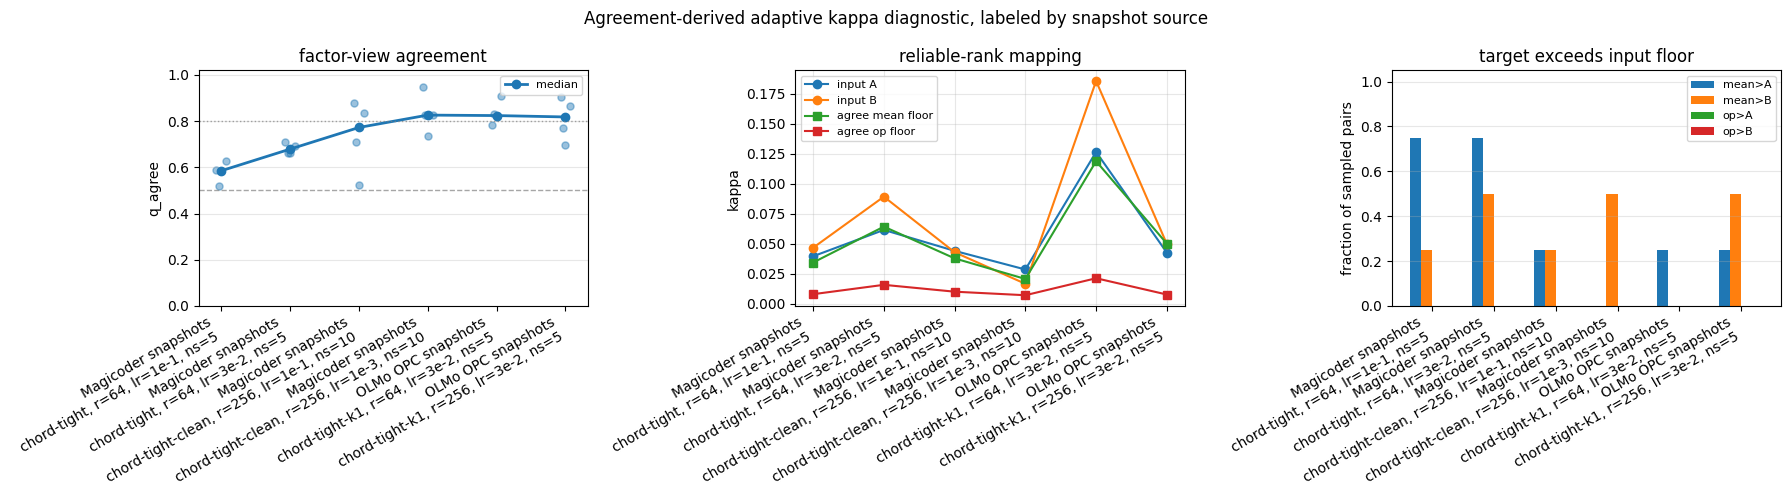

In [23]:
plot_df = df_agree.copy()
plot_df['mean_gt_input_A'] = plot_df.kappa_agree_meanfloor > plot_df.kappa_input_A
plot_df['mean_gt_input_B'] = plot_df.kappa_agree_meanfloor > plot_df.kappa_input_B
plot_df['op_gt_input_A'] = plot_df.kappa_agree_opfloor > plot_df.kappa_input_A
plot_df['op_gt_input_B'] = plot_df.kappa_agree_opfloor > plot_df.kappa_input_B

med = plot_df.groupby(agree_idx).median(numeric_only=True).reset_index()
rate = plot_df.groupby(agree_idx)[[
    'mean_gt_input_A', 'mean_gt_input_B', 'op_gt_input_A', 'op_gt_input_B'
]].mean().reset_index()
labels = [f'{src}\n{v}, r={r}, lr={lr}, ns={ns}'
          for src, v, r, lr, ns in med[agree_idx].itertuples(index=False, name=None)]
x = np.arange(len(med))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.0))

# Direct agreement score: individual sampled pairs plus run medians.
for i, row in med.iterrows():
    sub = plot_df[
        (plot_df.source_short == row.source_short)
        & (plot_df.variant == row.variant)
        & (plot_df.lora_r == row.lora_r)
        & (plot_df.lr == row.lr)
        & (plot_df.ns == row.ns)
    ]
    jitter = ((sub['pair'].to_numpy() % 5) - 2) * 0.035
    axes[0].scatter(np.full(len(sub), i) + jitter, sub['q_agree'],
                    color='C0', alpha=0.45, s=26)
axes[0].plot(x, med['q_agree'], color='C0', marker='o', lw=2.0,
             label='median')
axes[0].axhline(0.5, color='gray', ls='--', lw=1.0, alpha=0.7)
axes[0].axhline(0.8, color='gray', ls=':', lw=1.0, alpha=0.7)
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel('q_agree')
axes[0].set_title('factor-view agreement')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(x, med['kappa_input_A'], marker='o', label='input A')
axes[1].plot(x, med['kappa_input_B'], marker='o', label='input B')
axes[1].plot(x, med['kappa_agree_meanfloor'], marker='s', label='agree mean floor')
axes[1].plot(x, med['kappa_agree_opfloor'], marker='s', label='agree op floor')
axes[1].set_ylabel('kappa')
axes[1].set_title('reliable-rank mapping')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

w = 0.18
axes[2].bar(x - 1.5*w, rate['mean_gt_input_A'], width=w, label='mean>A')
axes[2].bar(x - 0.5*w, rate['mean_gt_input_B'], width=w, label='mean>B')
axes[2].bar(x + 0.5*w, rate['op_gt_input_A'], width=w, label='op>A')
axes[2].bar(x + 1.5*w, rate['op_gt_input_B'], width=w, label='op>B')
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel('fraction of sampled pairs')
axes[2].set_title('target exceeds input floor')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=30, ha='right')
axes[2].grid(True, axis='y', alpha=0.3)
axes[2].legend(fontsize=8)

fig.suptitle('Agreement-derived adaptive kappa diagnostic, labeled by snapshot source')
fig.tight_layout()
plt.show()


### Cell B — singular-value mechanism check

Side-by-side spectrum overlay of $X$, $H_c(X)$, and exact polar$(X)$ (SVD $U V^T$, all $\sigma=1$). The point: SSC caps the top while preserving the tail, vs. polar which inflates every $\sigma$ toward 1. This visually distinguishes SSC ("rank-preserving") from htmuon_p / $\sigma^p$ ("rank-inflating").

Source: default `load_snapshot(step)` uses RUN_A, i.e. **Magicoder snapshots** (`data/magicoder_seq512_70k_packed`, `packed_v1`, seq512, 4k-step snapshots).


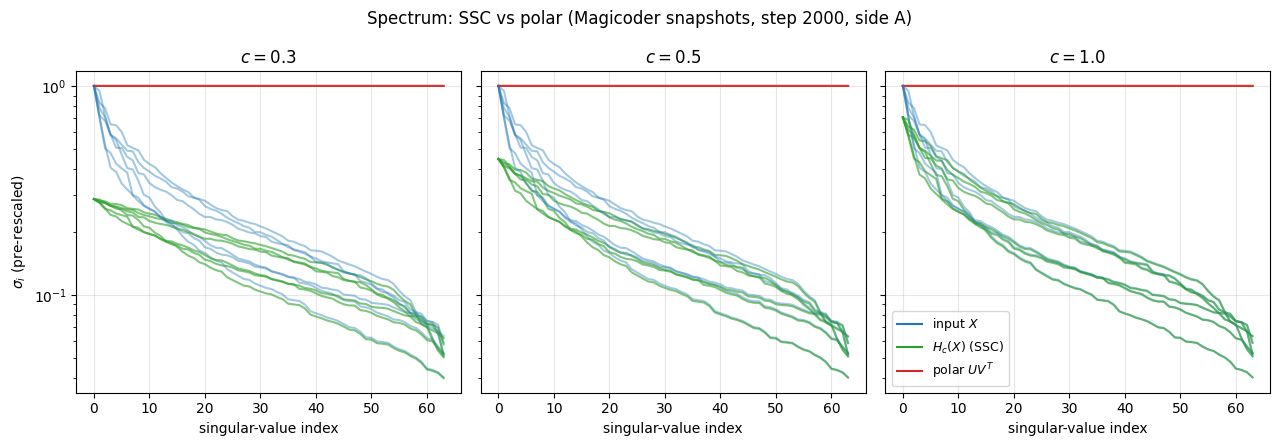

In [24]:
# _polar_uvt lives in lora_playground.snapshot_analysis.ssc.
def plot_ssc_spectrum_overlay(step=2000, cs=(0.3, 0.5, 1.0), n_pairs=6, side='A', device=SSC_DEV):
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)
    fig, axes = plt.subplots(1, len(cs), figsize=(4.3 * len(cs), 4.5), sharey=True)
    for ax, c in zip(axes, cs):
        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            X = _prerescale_unit_op(whitened_NS_input(p, side=side).to(device))
            s_X = torch.linalg.svdvals(X).cpu().numpy()
            s_H = torch.linalg.svdvals(_ssc_svd(X, c)).cpu().numpy()
            s_P = torch.linalg.svdvals(_polar_uvt(X)).cpu().numpy()
            ax.plot(s_X, color='C0', alpha=0.4)
            ax.plot(s_H, color='C2', alpha=0.6)
            ax.plot(s_P, color='C3', alpha=0.35)
        ax.set_title(rf'$c = {c}$')
        ax.set_xlabel('singular-value index')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    from matplotlib.lines import Line2D
    axes[0].set_ylabel(r'$\sigma_i$ (pre-rescaled)')
    axes[-1].legend([Line2D([],[],color='C0'), Line2D([],[],color='C2'), Line2D([],[],color='C3')],
                    [r'input $X$', r'$H_c(X)$ (SSC)', r'polar $UV^T$'],
                    loc='lower left', fontsize=9)
    fig.suptitle(f'Spectrum: SSC vs polar ({run_source_label(RUN_A)}, step {step}, side {side})')
    fig.tight_layout()
    return fig

plot_ssc_spectrum_overlay(2000, cs=(0.3, 0.5, 1.0))
plt.show()


### Cell C — MISR ↔ SVD agreement on real snapshots

For each retained $c$, compute SSC via the Newton-Schulz Algorithm 2 (MISR) routine `_ssc_misr_batched` and compare to the SVD reference `_ssc_svd`. Pass criterion: relative F-norm error $< 10^{-3}$ at $K=10$ across all snapshot pairs.

Source: default `load_snapshot(step)` uses RUN_A, i.e. **Magicoder snapshots** (`data/magicoder_seq512_70k_packed`, `packed_v1`, seq512, 4k-step snapshots).


In [25]:
def ssc_misr_vs_svd(steps=(200, 1000, 2000, 4000),
                    cs=(0.3, 0.5, 1.0, 3.0),
                    Ks=(5, 10, 15),
                    n_pairs=12, side='A', device=SSC_DEV):
    rows = []
    for step in steps:
        try:
            snap = load_snapshot(step)
        except FileNotFoundError:
            continue
        n_total = len(snap['pair_state'])
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)
        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            X = _prerescale_unit_op(whitened_NS_input(p, side=side).to(device))
            for c in cs:
                ref = _ssc_svd(X, c).float()
                ref_norm = ref.norm().item()
                for K in Ks:
                    ns = _ssc_misr_batched(X, c, nsteps=K)
                    err = (ns - ref).norm().item() / max(ref_norm, 1e-30)
                    rows.append({'step': step, 'pair': int(pi), 'c': c, 'K': K, 'rel_err': err})
    return pd.DataFrame(rows)

print(f'default snapshot source: {run_source_label(RUN_A)}')
df_misr = ssc_misr_vs_svd()
print('=== Relative F-norm error  ||MISR - SVD||_F / ||SVD||_F  (MAX over pairs x steps, c x K) ===')
print(df_misr.pivot_table(values='rel_err', index='c', columns='K', aggfunc='max').applymap(lambda x: f'{x:.2e}'))
print()
print('=== Median over pairs x steps ===')
print(df_misr.pivot_table(values='rel_err', index='c', columns='K', aggfunc='median').applymap(lambda x: f'{x:.2e}'))
print()
print('PASS criterion: max rel_err at K=10 < 1e-3 for every c.')
max_at_10 = df_misr[df_misr.K == 10].groupby('c')['rel_err'].max()
print(max_at_10)


default snapshot source: Magicoder snapshots
=== Relative F-norm error  ||MISR - SVD||_F / ||SVD||_F  (MAX over pairs x steps, c x K) ===
K          5         10        15
c                                
0.3  2.64e-01  8.64e-06  8.65e-06
0.5  2.33e-01  9.30e-06  9.32e-06
1.0  2.22e-01  1.02e-05  1.02e-05
3.0  2.31e-01  1.19e-05  1.19e-05

=== Median over pairs x steps ===
K          5         10        15
c                                
0.3  2.37e-01  7.19e-06  7.21e-06
0.5  2.03e-01  7.72e-06  7.74e-06
1.0  2.01e-01  8.55e-06  8.55e-06
3.0  2.26e-01  9.41e-06  9.41e-06

PASS criterion: max rel_err at K=10 < 1e-3 for every c.
c
0.3    0.000009
0.5    0.000009
1.0    0.000010
3.0    0.000012
Name: rel_err, dtype: float64


/tmp/ipykernel_2880412/1140164444.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_misr.pivot_table(values='rel_err', index='c', columns='K', aggfunc='max').applymap(lambda x: f'{x:.2e}'))
/tmp/ipykernel_2880412/1140164444.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_misr.pivot_table(values='rel_err', index='c', columns='K', aggfunc='median').applymap(lambda x: f'{x:.2e}'))
